# Empirical distributions

Every exact distribution `phasegen` computes can also be *sampled*. {meth}`~phasegen.distributions.PhaseTypeDistribution.to_empirical` draws genealogies from the same phase-type generator and returns an empirical counterpart ({class}`~phasegen.distributions.EmpiricalPhaseTypeDistribution`) that exposes the same interface as the exact {class}`~phasegen.distributions.PhaseTypeDistribution`, only estimated by Monte Carlo rather than the exact matrix computation.

```{versionadded} 2.0
```

This serves two purposes. First, a fast, independent check that the exact results are right. Second, because the sampler is fully vectorised, a fallback for state spaces too large for the exact computation to remain tractable.

In [1]:
import os
os.environ['TQDM_DISABLE'] = '1'  # silence msprime simulation progress bars in the docs

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (5, 4)

In [2]:
import phasegen as pg

In [3]:
# keep the rendered docs clean: silence informational logging and warnings
import logging
import warnings

logging.getLogger('phasegen').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

## Sampling a spectrum

Take a two-population demography with a size change and asymmetric migration. {meth}`~phasegen.distributions.JointSFSDistribution.to_empirical` draws genealogies from this model and bins each one's branch lengths into the joint SFS; its `mean` is the sampled counterpart of the exact {meth}`~phasegen.distributions.Coalescent.jsfs`.

In [4]:
coal = pg.Coalescent(
    n={'pop_0': 4, 'pop_1': 4},
    demography=pg.Demography(
        pop_sizes={'pop_0': {0: 1, 1: 0.3}, 'pop_1': {0: 1.5}},
        migration_rates={('pop_0', 'pop_1'): 0.5, ('pop_1', 'pop_0'): 0.2},
    ),
)

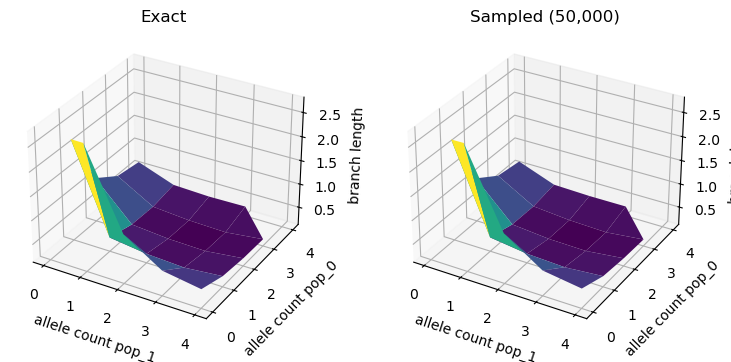

In [5]:
# the sampled mean joint SFS reproduces the exact surface from 50,000 genealogies
sampled = coal.jsfs.to_empirical(50_000)

_, axs = plt.subplots(ncols=2, figsize=(9, 4), subplot_kw={'projection': '3d'})
coal.jsfs.mean.plot_surface(ax=axs[0], show=False, title='Exact')
sampled.mean.plot_surface(ax=axs[1], title='Sampled (50,000)');

Because the empirical object exposes the *same* interface as the exact distribution, scalar summaries compare directly. A hundred thousand genealogies recover the exact tree height and total branch length to three digits.

In [6]:
th = coal.tree_height.to_empirical(100_000)
tbl = coal.total_branch_length.to_empirical(100_000)

print(f"{'':<22}{'exact':>10}{'sampled':>10}")
print(f"{'tree height (mean)':<22}{coal.tree_height.mean:>10.3f}{th.mean:>10.3f}")
print(f"{'tree height (var)':<22}{coal.tree_height.var:>10.3f}{th.var:>10.3f}")
print(f"{'branch length (mean)':<22}{coal.total_branch_length.mean:>10.3f}{tbl.mean:>10.3f}")

                           exact   sampled
tree height (mean)         4.794     4.783
tree height (var)          8.442     8.389
branch length (mean)      14.033    14.047


## Speed and scaling

The sampler is fully vectorised and fast, drawing a few hundred thousand genealogies in a fraction of a second. Its cost grows with the number of samples rather than with the size of the state space, so it keeps working where the exact matrix exponential becomes intractable: very large sample sizes, or many populations or loci. Where the exact computation is feasible it remains preferable, being exact and free of Monte-Carlo error; sampling is the fallback when it is not.

## msprime ground truth

{meth}`~phasegen.distributions.Coalescent.to_msprime` returns an `msprime`-backed coalescent ({class}`~phasegen.distributions.MsprimeCoalescent`) with the same interface. Where `to_empirical` is PhaseGen's own sampler, this is a fully independent implementation: an external ground truth rather than a self-consistency check, at the cost of the slower, non-vectorised `msprime` simulation. PhaseGen's exact results are extensively validated against msprime across a wide range of scenarios.

In [7]:
ms = coal.to_msprime(num_replicates=5_000, seed=42)

print(f"tree height mean   exact = {coal.tree_height.mean:.3f}   msprime = {ms.tree_height.mean:.3f}")

tree height mean   exact = 4.794   msprime = 4.749
